In [1]:
# Phase 4 prep – ICIO country summaries (fix Phase-2 limitation)

from pathlib import Path
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
ICIO_DIR = PROJECT / "data" / "raw" / "oecd_icio"
OUT_DATA = PROJECT / "outputs" / "phase4" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase4" / "tables"
for d in [OUT_DATA, OUT_TAB]:
    d.mkdir(parents=True, exist_ok=True)

cw = pd.read_pickle(PROJECT / "outputs" / "phase1" / "data" / "country_crosswalk.pkl")
iso3_set = set(cw["iso3"])
YEAR_MIN, YEAR_MAX = 2000, 2020

print("=" * 60)
print("Phase 4 prep – ICIO country-level clean summaries")
print("=" * 60)

files = sorted(ICIO_DIR.glob("*_SML.csv"))
years = [int(f.stem.split("_")[0]) for f in files]
years = [y for y in years if YEAR_MIN <= y <= YEAR_MAX]
print(f"ICIO years used: {min(years)}–{max(years)} | n={len(years)}")

records = []
for y in years:
    f = ICIO_DIR / f"{y}_SML.csv"
    df = pd.read_csv(f, index_col=0, low_memory=False)
    # row/col labels like AUS_A01, USA_HFCE, ...
    cols = df.columns.astype(str)
    idx = df.index.astype(str)

    for cty in iso3_set:
        # Output (OUT column if exists) or row sum as proxy output
        out_col = "OUT" if "OUT" in cols else None
        row_mask = idx.str.startswith(cty + "_")
        # industry rows only (exclude FD-like if any in index)
        ind_rows = idx[row_mask & ~idx.str.contains("HFCE|NPISH|GGFC|GFCF|INVNT|DPABR|TLS|VA|OUT", regex=True)]

        # Final demand received by country (HFCE, GGFC)
        hfce_cols = [c for c in cols if c == f"{cty}_HFCE"]
        ggfc_cols = [c for c in cols if c == f"{cty}_GGFC"]

        try:
            output = float(df.loc[ind_rows, out_col].sum()) if out_col and len(ind_rows) else float(df.loc[ind_rows].sum(axis=1).sum())
        except Exception:
            output = np.nan
        try:
            hfce = float(df.loc[ind_rows, hfce_cols].sum().sum()) if hfce_cols else np.nan
        except Exception:
            hfce = np.nan
        try:
            ggfc = float(df.loc[ind_rows, ggfc_cols].sum().sum()) if ggfc_cols else np.nan
        except Exception:
            ggfc = np.nan

        records.append({
            "year": y, "iso3": cty,
            "icio_output": output,
            "icio_hfce": hfce,
            "icio_ggfc": ggfc,
        })

icio_sum = pd.DataFrame(records)
# clean: replace non-positive / inf
for c in ["icio_output", "icio_hfce", "icio_ggfc"]:
    icio_sum[c] = pd.to_numeric(icio_sum[c], errors="coerce")
    icio_sum.loc[~np.isfinite(icio_sum[c]), c] = np.nan
    icio_sum.loc[icio_sum[c] < 0, c] = np.nan

# light outlier winsorize within year (1%-99%)
for c in ["icio_output", "icio_hfce", "icio_ggfc"]:
    icio_sum[c] = icio_sum.groupby("year")[c].transform(
        lambda s: s.clip(lower=s.quantile(0.01), upper=s.quantile(0.99))
    )

print(icio_sum.describe().round(2).to_string())
print(f"\nMissing pct:\n{icio_sum.isna().mean().round(3)}")

icio_sum.to_pickle(OUT_DATA / "icio_country_summary_clean.pkl")
icio_sum.to_csv(OUT_TAB / "icio_country_summary_clean.csv", index=False)
print(f"\nSaved → {OUT_DATA / 'icio_country_summary_clean.pkl'}")
print("Cell 0 completed successfully.")

Phase 4 prep – ICIO country-level clean summaries
ICIO years used: 2000–2020 | n=21
          year  icio_output    icio_hfce   icio_ggfc
count   378.00       378.00       378.00      378.00
mean   2010.00   3615901.42    965639.28   361023.53
std       6.06   5613809.78   1830859.99   498058.21
min    2000.00    209782.01     32926.68    15847.28
25%    2005.00    620185.12    107633.34    68935.29
50%    2010.00   1528126.84    283749.18   168311.21
75%    2015.00   4165330.07   1006971.38   459896.57
max    2020.00  32389538.10  10661446.11  2813391.17

Missing pct:
year           0.0
iso3           0.0
icio_output    0.0
icio_hfce      0.0
icio_ggfc      0.0
dtype: float64

Saved → D:\univercity\omid_project\economics_project\outputs\phase4\data\icio_country_summary_clean.pkl
Cell 0 completed successfully.


In [2]:
# Phase 4 – Temporal Network Construction | Cell 1: Setup + Load

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import networkx as nx

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR  = PROJECT / "outputs" / "phase4"
OUT_DATA = OUT_DIR / "data"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"
for d in [OUT_DATA, OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Phase 4 – Temporal Network Construction | Cell 1")
print("=" * 60)
print(f"Timestamp    : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Project Root : {PROJECT}")
print(f"Outputs      : {OUT_DIR}")

edges = pd.read_pickle(PROJECT / "outputs" / "phase1" / "data" / "baci_edges_jst18.pkl")
nodes = pd.read_pickle(PROJECT / "outputs" / "phase1" / "data" / "baci_nodes_jst18.pkl")
panel = pd.read_pickle(PROJECT / "outputs" / "phase2" / "data" / "panel_final_clean.pkl")
cw    = pd.read_pickle(PROJECT / "outputs" / "phase1" / "data" / "country_crosswalk.pkl")

print(f"\nBACI edges : {edges.shape}")
print(f"BACI nodes : {nodes.shape}")
print(f"Panel      : {panel.shape}")
print(f"Years      : {edges['year'].min()} – {edges['year'].max()}")
print(f"Countries  : {edges['source_iso2'].nunique()}")

print("\nCell 1 completed successfully.")

Phase 4 – Temporal Network Construction | Cell 1
Timestamp    : 2026-09-25 20:56:52
Project Root : D:\univercity\omid_project\economics_project
Outputs      : D:\univercity\omid_project\economics_project\outputs\phase4

BACI edges : (6426, 14)
BACI nodes : (378, 8)
Panel      : (378, 75)
Years      : 2000 – 2020
Countries  : 18

Cell 1 completed successfully.


In [3]:
# Phase 4 – Temporal Network Construction | Cell 2: Build yearly trade networks

from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase4" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase4" / "tables"

print("=" * 60)
print("Phase 4 – Temporal Network Construction | Cell 2")
print("=" * 60)

edges = pd.read_pickle(PROJECT / "outputs" / "phase1" / "data" / "baci_edges_jst18.pkl").copy()
cw = pd.read_pickle(PROJECT / "outputs" / "phase1" / "data" / "country_crosswalk.pkl")

# clean weights
edges["weight"] = pd.to_numeric(edges["weight_value_kusd"], errors="coerce").fillna(0.0)
edges = edges[edges["weight"] > 0]
edges = edges[edges["source_iso2"] != edges["target_iso2"]]

years = sorted(edges["year"].unique())
print(f"Years: {years[0]}–{years[-1]} | n={len(years)}")
print(f"Nodes (iso2): {sorted(cw['iso2'].unique())}")

networks = {}
meta_rows = []

for y in years:
    g = nx.DiGraph()
    g.add_nodes_from(cw["iso2"].tolist())
    sub = edges[edges["year"] == y]
    for _, r in sub.iterrows():
        g.add_edge(r["source_iso2"], r["target_iso2"], weight=float(r["weight"]))

    n_nodes = g.number_of_nodes()
    n_edges = g.number_of_edges()
    total_w = float(np.sum([d["weight"] for _, _, d in g.edges(data=True)])) if n_edges else 0.0
    density = nx.density(g) if n_nodes > 1 else 0.0

    networks[(y)] = g
    meta_rows.append({
        "year": y,
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "total_weight": total_w,
        "density": density,
    })

meta = pd.DataFrame(meta_rows)
print("\n--- Network metadata (sample) ---")
print(meta.head(8).to_string(index=False))
print("...")
print(meta.tail(3).to_string(index=False))

with open(OUT_DATA / "temporal_trade_networks.pkl", "wb") as f:
    pickle.dump(networks, f)
meta.to_csv(OUT_TAB / "network_metadata.csv", index=False)

print(f"\nTotal snapshots: {len(networks)}")
print(f"Saved → {OUT_DATA / 'temporal_trade_networks.pkl'}")
print("\nCell 2 completed successfully.")

Phase 4 – Temporal Network Construction | Cell 2
Years: 2000–2020 | n=21
Nodes (iso2): ['AU', 'BE', 'CA', 'CH', 'DE', 'DK', 'ES', 'FI', 'FR', 'GB', 'IE', 'IT', 'JP', 'NL', 'NO', 'PT', 'SE', 'US']

--- Network metadata (sample) ---
 year  n_nodes  n_edges  total_weight  density
 2000       18      306  2.624544e+09      1.0
 2001       18      306  2.534824e+09      1.0
 2002       18      306  2.600256e+09      1.0
 2003       18      306  2.907138e+09      1.0
 2004       18      306  3.348376e+09      1.0
 2005       18      306  3.630738e+09      1.0
 2006       18      306  3.977557e+09      1.0
 2007       18      306  4.396310e+09      1.0
...
 year  n_nodes  n_edges  total_weight  density
 2018       18      306  4.660054e+09      1.0
 2019       18      306  4.543209e+09      1.0
 2020       18      306  4.171468e+09      1.0

Total snapshots: 21
Saved → D:\univercity\omid_project\economics_project\outputs\phase4\data\temporal_trade_networks.pkl

Cell 2 completed successfully.


In [4]:
# Phase 4 – Temporal Network Construction | Cell 3: Structural Metrics

from pathlib import Path
import pandas as pd
import numpy as np
import networkx as nx
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase4" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase4" / "tables"

print("=" * 60)
print("Phase 4 – Temporal Network Construction | Cell 3")
print("=" * 60)

with open(OUT_DATA / "temporal_trade_networks.pkl", "rb") as f:
    networks = pickle.load(f)

rows = []
for y, g in sorted(networks.items(), key=lambda x: x[0]):
    weights = [d.get("weight", 0.0) for _, _, d in g.edges(data=True)]
    total_w = float(np.sum(weights)) if weights else 0.0
    in_str = dict(g.in_degree(weight="weight"))
    out_str = dict(g.out_degree(weight="weight"))

    rows.append({
        "year": y,
        "n_nodes": g.number_of_nodes(),
        "n_edges": g.number_of_edges(),
        "total_weight": total_w,
        "density": nx.density(g),
        "avg_in_strength": float(np.mean(list(in_str.values()))) if in_str else 0.0,
        "avg_out_strength": float(np.mean(list(out_str.values()))) if out_str else 0.0,
        "max_in_strength": float(np.max(list(in_str.values()))) if in_str else 0.0,
        "max_out_strength": float(np.max(list(out_str.values()))) if out_str else 0.0,
    })

metrics = pd.DataFrame(rows)
print("--- Structural metrics (sample) ---")
print(metrics.head(8).to_string(index=False))
print("\n--- total_weight summary ---")
print(metrics["total_weight"].describe().to_string())

metrics.to_csv(OUT_TAB / "network_structural_metrics.csv", index=False)
metrics.to_pickle(OUT_DATA / "network_structural_metrics.pkl")

# keep cleaned copy of networks (already clean weights)
with open(OUT_DATA / "temporal_trade_networks_clean.pkl", "wb") as f:
    pickle.dump(networks, f)

print(f"\nSaved metrics + clean networks")
print("\nCell 3 completed successfully.")

Phase 4 – Temporal Network Construction | Cell 3
--- Structural metrics (sample) ---
 year  n_nodes  n_edges  total_weight  density  avg_in_strength  avg_out_strength  max_in_strength  max_out_strength
 2000       18      306  2.624544e+09      1.0     1.458080e+08      1.458080e+08     5.948763e+08      4.298912e+08
 2001       18      306  2.534824e+09      1.0     1.408236e+08      1.408236e+08     5.586810e+08      3.943683e+08
 2002       18      306  2.600256e+09      1.0     1.444587e+08      1.444587e+08     5.665887e+08      4.012023e+08
 2003       18      306  2.907138e+09      1.0     1.615077e+08      1.615077e+08     5.930827e+08      4.714358e+08
 2004       18      306  3.348376e+09      1.0     1.860209e+08      1.860209e+08     6.698714e+08      5.533914e+08
 2005       18      306  3.630738e+09      1.0     2.017077e+08      2.017077e+08     7.371393e+08      5.971587e+08
 2006       18      306  3.977557e+09      1.0     2.209754e+08      2.209754e+08     7.790085e+

Phase 4 – Temporal Network Construction | Cell 4
--- Yearly metrics ---
 year  total_weight  avg_in_strength  density  n_edges
 2000  2.624544e+09     1.458080e+08      1.0      306
 2001  2.534824e+09     1.408236e+08      1.0      306
 2002  2.600256e+09     1.444587e+08      1.0      306
 2003  2.907138e+09     1.615077e+08      1.0      306
 2004  3.348376e+09     1.860209e+08      1.0      306
 2005  3.630738e+09     2.017077e+08      1.0      306
 2006  3.977557e+09     2.209754e+08      1.0      306
 2007  4.396310e+09     2.442395e+08      1.0      306
 2008  4.731994e+09     2.628886e+08      1.0      306
 2009  3.579757e+09     1.988754e+08      1.0      306
 2010  3.957334e+09     2.198519e+08      1.0      306
 2011  4.584491e+09     2.546939e+08      1.0      306
 2012  4.433635e+09     2.463131e+08      1.0      306
 2013  4.431106e+09     2.461726e+08      1.0      306
 2014  4.550309e+09     2.527949e+08      1.0      306
 2015  4.011490e+09     2.228606e+08      1.0   

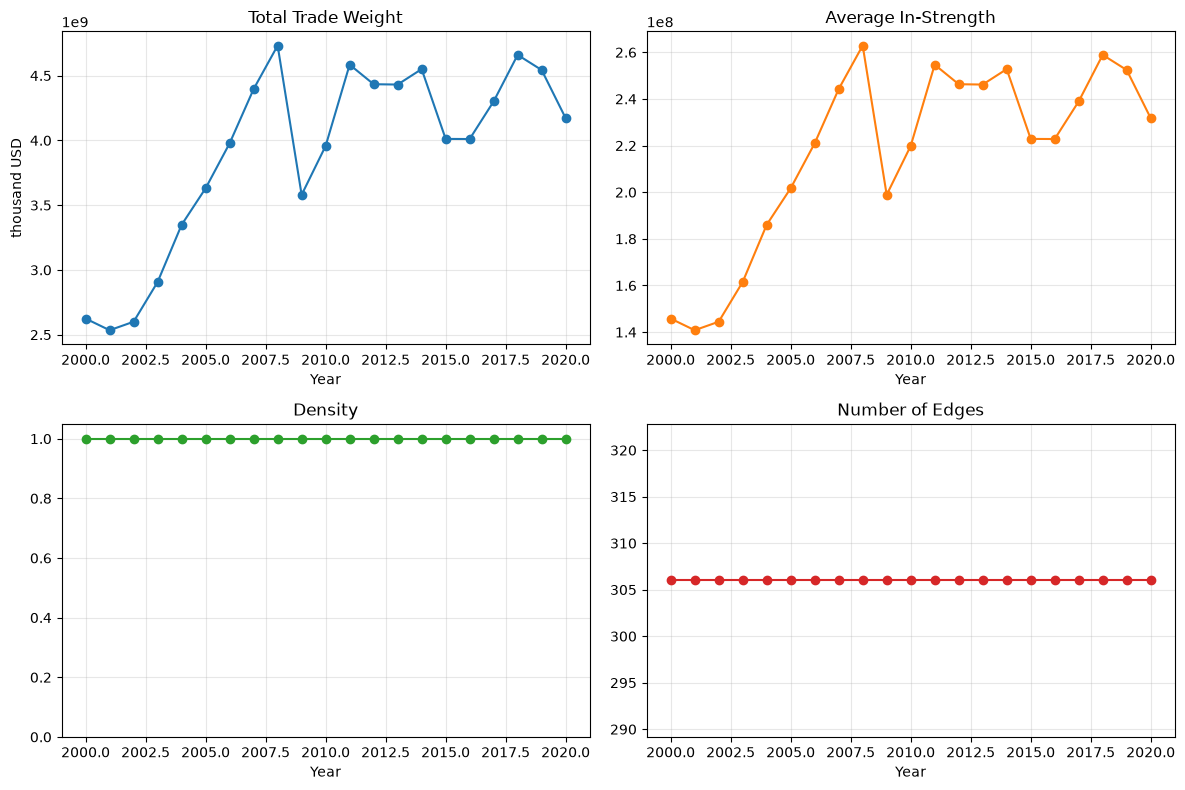


Saved figure → D:\univercity\omid_project\economics_project\outputs\phase4\figures\network_evolution_over_time.png

Cell 4 completed successfully.
PHASE 4 COMPLETED.


In [5]:
# Phase 4 – Temporal Network Construction | Cell 4: Evolution Summary

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase4" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase4" / "tables"
OUT_FIG  = PROJECT / "outputs" / "phase4" / "figures"

print("=" * 60)
print("Phase 4 – Temporal Network Construction | Cell 4")
print("=" * 60)

metrics = pd.read_pickle(OUT_DATA / "network_structural_metrics.pkl")

print("--- Yearly metrics ---")
print(metrics[["year", "total_weight", "avg_in_strength", "density", "n_edges"]].to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

axes[0].plot(metrics["year"], metrics["total_weight"], marker="o")
axes[0].set_title("Total Trade Weight")
axes[0].set_ylabel("thousand USD")

axes[1].plot(metrics["year"], metrics["avg_in_strength"], marker="o", color="tab:orange")
axes[1].set_title("Average In-Strength")

axes[2].plot(metrics["year"], metrics["density"], marker="o", color="tab:green")
axes[2].set_title("Density")
axes[2].set_ylim(0, 1.05)

axes[3].plot(metrics["year"], metrics["n_edges"], marker="o", color="tab:red")
axes[3].set_title("Number of Edges")

for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Year")

plt.tight_layout()
fig.savefig(OUT_FIG / "network_evolution_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

metrics.to_csv(OUT_TAB / "network_evolution_summary.csv", index=False)
print(f"\nSaved figure → {OUT_FIG / 'network_evolution_over_time.png'}")
print("\nCell 4 completed successfully.")
print("PHASE 4 COMPLETED.")